In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


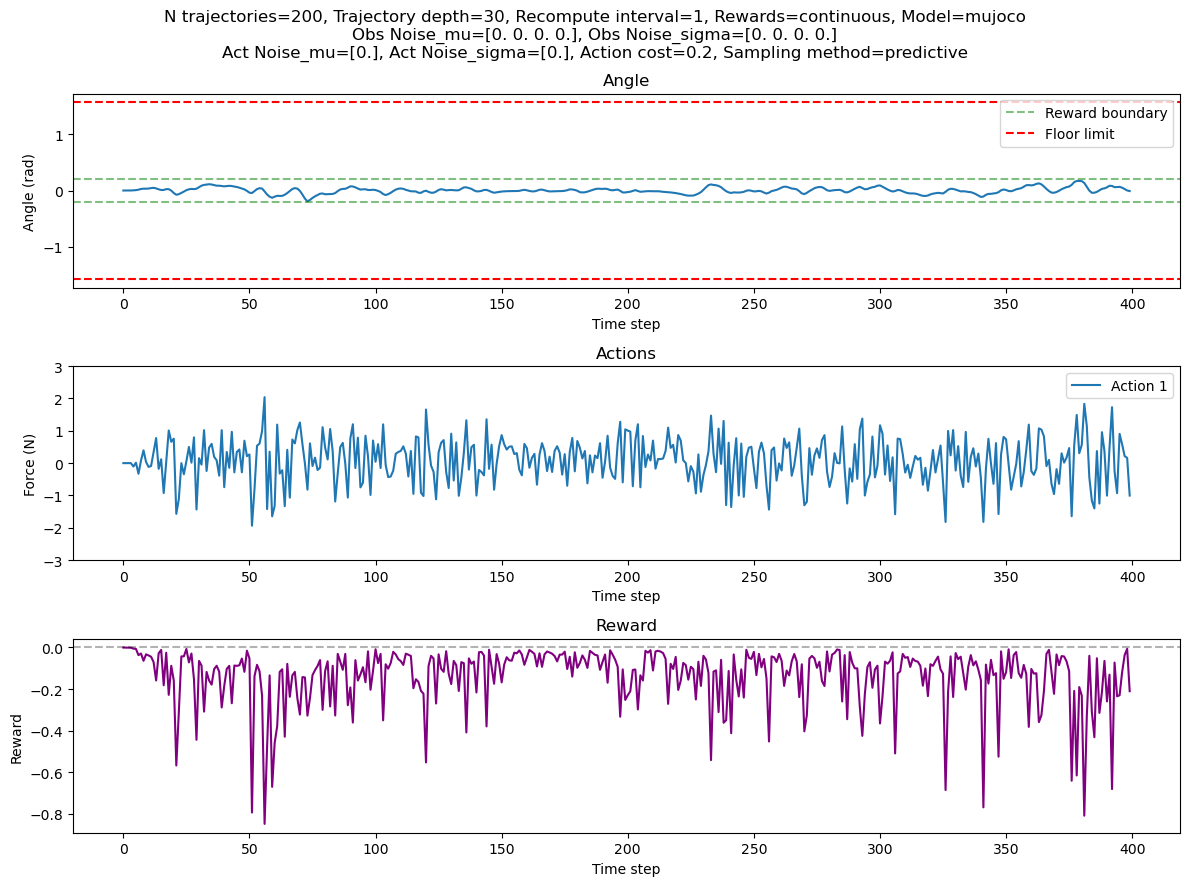

In [2]:
# Simulate the bird
planning_width = 200 # how many trajectories to simulate
n_planning = 30 # how deep the rolout of each trajectory is
recompute_interval = 1
n_episodes = 1 
time_steps = 400
reward_type='continuous' # rewards can be 'discrete' or 'continuous'
model_type='mujoco' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model
obs_noise_mu=np.array([0.0, 0.0, 0.0, 0.0]) # mean of the noise added to the observations
obs_noise_sigma=np.array([0.0, 0.0, 0.0, 0.0]) # standard deviation of the noise added to the observations
act_noise_mu=np.array([0.0]) # mean of the noise added to the actions
act_noise_sigma=np.array([0.0]) # standard deviation of the noise added to the actions
action_cost = 0.2
sampling_method = 'predictive' # sampling method can be 'predictive' or 'random'

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type, action_cost=action_cost, sampling_method='predictive')

# Simulate the bird
simulation_data = simulate_one_model(bird, n_episodes=n_episodes, time_steps=time_steps,recompute_interval=recompute_interval, obs_noise_mu=obs_noise_mu, obs_noise_sigma=obs_noise_sigma, act_noise_mu=act_noise_mu, act_noise_sigma=act_noise_sigma, reward_type=reward_type, action_cost=action_cost)

episode1 = simulation_data["episode_1"]

angle = episode1["state_2"]

reward = episode1["reward"]

# Gather all action dimensions into a 2D array (time_steps, act_dim)
action_keys = sorted([k for k in episode1 if k.startswith("action_")])  # sorted for order
actions = np.vstack([episode1[k] for k in action_keys]).T

plt.figure(figsize=(12, 9))  # Made figure taller to accommodate third subplot
plt.suptitle(
    f'N trajectories={planning_width}, Trajectory depth={n_planning}, Recompute interval={recompute_interval}, Rewards={reward_type}, Model={model_type}\n'
    f'Obs Noise_mu={obs_noise_mu}, Obs Noise_sigma={obs_noise_sigma}\n'
    f'Act Noise_mu={act_noise_mu}, Act Noise_sigma={act_noise_sigma}, Action cost={action_cost}, Sampling method={sampling_method}',
    fontsize=12
)

# Plot the angle
plt.subplot(3, 1, 1)  # Changed to 3 rows
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward boundary')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor limit')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(3, 1, 2)  # Changed to 3 rows
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)
plt.legend([f'Action {i+1}' for i in range(actions.shape[1])], loc='upper right')

# Add reward subplot
plt.subplot(3, 1, 3)
plt.plot(reward, 'purple')
plt.title('Reward')
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



In [3]:
single_sim_config = {
    'planning_width': 200,
    'reward_type': 'continuous',
    'model_type': 'mujoco',
    'obs_noise_mu': np.array([0.0, 0.0, 0.0, 0.0]),
    'obs_noise_sigma': np.array([0.0, 0.0, 0.0, 0.0]),
    'act_noise_mu': np.array([0.0]),
    'act_noise_sigma': np.array([0.0]),
    'n_episodes': 5,
    'time_steps': 10,
    'action_cost': 0.2,
    'sampling_method': 'predictive',
    'recompute_intervals': [1],         # Just one interval
    'n_planning_values': [1,2,3]            # Just one planning value
}

run_simulations(single_sim_config)

Created directory: ../results
Created directory: ../results/models
Starting simulations with 1 intervals and 3 planning values
Running simulation with recompute_interval=1, n_planning=1


Model result saved to ../results/models/model_interval1_planning1.pkl
Running simulation with recompute_interval=1, n_planning=2
Model result saved to ../results/models/model_interval1_planning2.pkl
Running simulation with recompute_interval=1, n_planning=3
Model result saved to ../results/models/model_interval1_planning3.pkl
Simulations completed in 4.22 seconds


'20250620-202700'

Loaded model from ../results/models/model_interval1_planning100_time20250620-204639.pkl
Loaded model from ../results/models/model_interval1_planning100_time20250620-204750.pkl
Loaded model from ../results/models/model_interval1_planning100_time20250620-204826.pkl
Loaded model from ../results/models/model_interval1_planning10_time20250620-204630.pkl
Loaded model from ../results/models/model_interval1_planning10_time20250620-204740.pkl
Loaded model from ../results/models/model_interval1_planning10_time20250620-204815.pkl
Loaded model from ../results/models/model_interval1_planning1_time20250620-204630.pkl
Loaded model from ../results/models/model_interval1_planning1_time20250620-204740.pkl
Loaded model from ../results/models/model_interval1_planning1_time20250620-204815.pkl
Loaded model from ../results/models/model_interval1_planning20_time20250620-204630.pkl
Loaded model from ../results/models/model_interval1_planning20_time20250620-204740.pkl
Loaded model from ../results/models/model_i

(<Figure size 1400x600 with 2 Axes>,
 {1: {'n_planning': [1, 10, 20, 30, 40, 50, 60, 70, 80, 90],
   'means': [-1.16192253331041,
    -1.0952666497871073,
    -1.1131953209162702,
    -0.3633824653924478,
    -0.1794638657811608,
    -0.19243107732467413,
    -0.21080310020525292,
    -0.21984230923948947,
    -0.22354839534786375,
    -0.2396745322841932],
   'std_errors': [0.002455554041435756,
    0.023026122984323,
    0.02526690318144024,
    0.03560837861395687,
    0.005930284459185473,
    0.0006996428111399597,
    0.0009557280877601826,
    0.0009283332919697689,
    0.0008720781006835174,
    0.013318972648814315]}},
 {1: {'n_planning': [1, 10, 20, 30, 40, 50, 60, 70, 80, 90],
   'means': [295.66,
    343.0,
    330.45,
    861.01,
    995.75,
    1000.0,
    1000.0,
    1000.0,
    1000.0,
    984.2],
   'std_errors': [1.7347441810645665,
    16.286519182155132,
    17.903802287883888,
    25.0982734928766,
    4.25,
    0.0,
    0.0,
    0.0,
    0.0,
    11.48052369199350

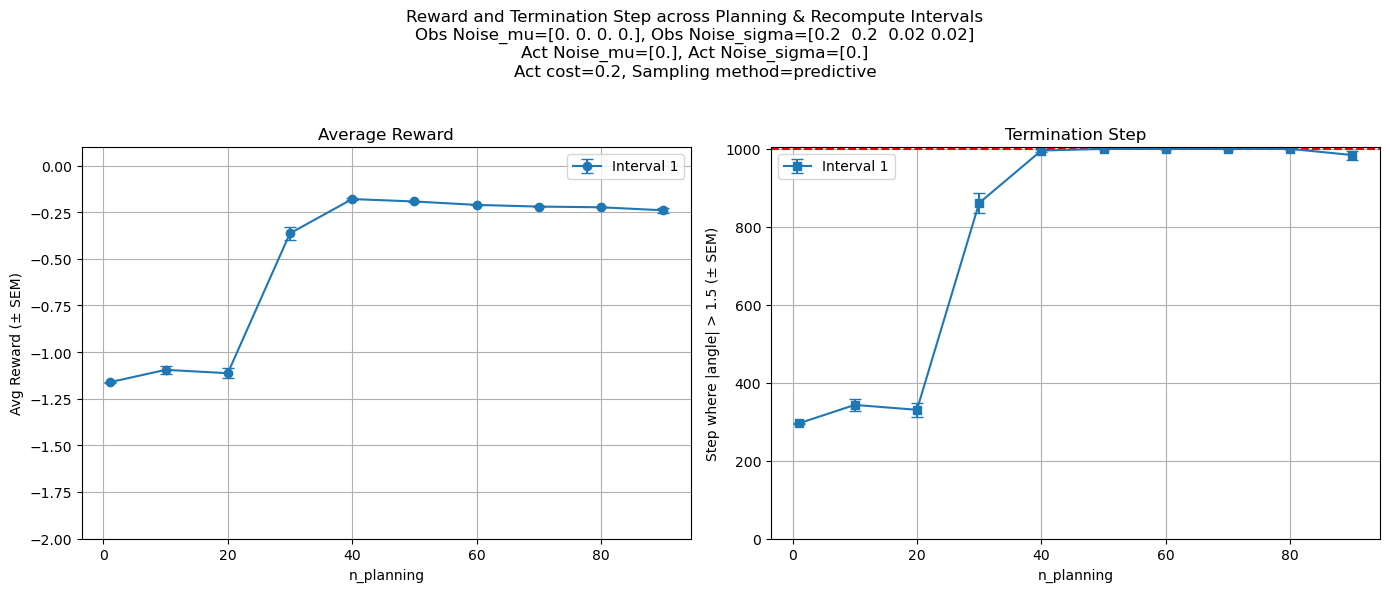

In [5]:
# Define configuration
plot_config = {
    'planning_width': 200,
    'reward_type': 'continuous',
    'model_type': 'mujoco',
    'obs_noise_mu': np.array([0.0, 0.0, 0.0, 0.0]), 
    'obs_noise_sigma': np.array([0.2, 0.2, 0.02, 0.02]), #0.0, 0.0, 0.0, 0.0 #0.2, 0.2, 0.02, 0.02 #0.4, 0.4, 0.04, 0.04
    'act_noise_mu': np.array([0.0]),
    'act_noise_sigma': np.array([0.0]),
    'n_episodes': 100,
    'time_steps': 1000,
    'action_cost': 0.2,
    'sampling_method': 'predictive',
    #'recompute_intervals': [1],  # Use the command line argument
    #'n_planning_values': [1,10]             # Use the command line argument
}

analyze_and_plot_results(plot_config)